**PART1.噪声生成部分**

In [1]:
import math
import numpy as np  
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
x_lst = [i/10 for i in range(0,100)]
y_true_lst = []
for i in x_lst:
    #图像修改处
    y_true_lst.append(2*i+1)


#噪声生成
noise_scale = 0.3
seed = 42  
np.random.seed(seed)  
'''
noise_gaussian = np.random.normal(0, noise_scale, len(x_lst))''
y_gaussian_lst = [y + noise for y, noise in zip(y_true_lst, noise_gaussian)]  高斯噪声
'''
noise_laplace = np.random.laplace(0, noise_scale, len(x_lst))
y_laplace_lst = [y + noise for y, noise in zip(y_true_lst, noise_laplace)]


print("y_true_lst:", y_true_lst)

y_true_lst: [1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.2, 3.4, 3.6, 3.8, 4.0, 4.2, 4.4, 4.6, 4.8, 5.0, 5.2, 5.4, 5.6, 5.8, 6.0, 6.2, 6.4, 6.6, 6.8, 7.0, 7.2, 7.4, 7.6, 7.8, 8.0, 8.2, 8.4, 8.6, 8.8, 9.0, 9.2, 9.4, 9.6, 9.8, 10.0, 10.2, 10.4, 10.6, 10.8, 11.0, 11.2, 11.4, 11.6, 11.8, 12.0, 12.2, 12.4, 12.6, 12.8, 13.0, 13.2, 13.4, 13.6, 13.8, 14.0, 14.2, 14.4, 14.6, 14.8, 15.0, 15.2, 15.4, 15.6, 15.8, 16.0, 16.2, 16.4, 16.6, 16.8, 17.0, 17.2, 17.4, 17.6, 17.8, 18.0, 18.2, 18.4, 18.6, 18.8, 19.0, 19.2, 19.4, 19.6, 19.8, 20.0, 20.2, 20.4, 20.6, 20.8]


**PART2.最小二乘算法拟合直线曲线**

y_true_lst: [1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.2, 3.4, 3.6, 3.8, 4.0, 4.2, 4.4, 4.6, 4.8, 5.0, 5.2, 5.4, 5.6, 5.8, 6.0, 6.2, 6.4, 6.6, 6.8, 7.0, 7.2, 7.4, 7.6, 7.8, 8.0, 8.2, 8.4, 8.6, 8.8, 9.0, 9.2, 9.4, 9.6, 9.8, 10.0, 10.2, 10.4, 10.6, 10.8, 11.0, 11.2, 11.4, 11.6, 11.8, 12.0, 12.2, 12.4, 12.6, 12.8, 13.0, 13.2, 13.4, 13.6, 13.8, 14.0, 14.2, 14.4, 14.6, 14.8, 15.0, 15.2, 15.4, 15.6, 15.8, 16.0, 16.2, 16.4, 16.6, 16.8, 17.0, 17.2, 17.4, 17.6, 17.8, 18.0, 18.2, 18.4, 18.6, 18.8, 19.0, 19.2, 19.4, 19.6, 19.8, 20.0, 20.2, 20.4, 20.6, 20.8]
最优系数：
[[ 1.06632051e+00]
 [ 1.81987645e+00]
 [ 6.79525138e-02]
 [-8.62140093e-03]
 [ 3.40994673e-04]]
均方根误差： [0.28686363]


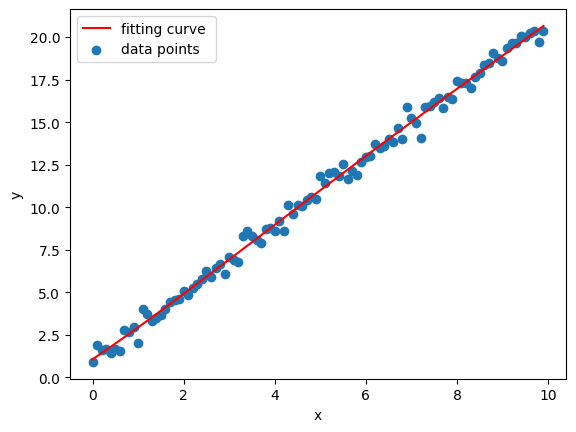

In [2]:
#最小二乘算法
'''
草稿：目标函数(M=3)
def predfuncx(x):
    return w0+ w1*x + w2*x**2 + w3*x**3

Ew=0
for i in range(0,101):
    Ew+=0.5*(y_laplace_lst[i]-predfuncx(x_lst[i]))**2

'''
import math
import numpy as np  
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
x_lst = [i/10 for i in range(0,100)]
y_true_lst = []
for i in x_lst:
    #图像修改处
    y_true_lst.append(2*i+1)


#噪声生成
noise_scale = 0.3
seed = 42  
np.random.seed(seed)  
'''
noise_gaussian = np.random.normal(0, noise_scale, len(x_lst))''
y_gaussian_lst = [y + noise for y, noise in zip(y_true_lst, noise_gaussian)]  高斯噪声
'''
noise_laplace = np.random.laplace(0, noise_scale, len(x_lst))
y_laplace_lst = [y + noise for y, noise in zip(y_true_lst, noise_laplace)]


print("y_true_lst:", y_true_lst)
M=4
N=len(x_lst)
#矩阵设计与求解
X_mat = np.zeros((N, M+1))
for n in range(N):
    for j in range(M+1):
        X_mat[n, j] = x_lst[n] ** j 
T = np.array(y_laplace_lst).reshape(-1, 1)
X_mat_T = X_mat.T  
temp = np.dot(X_mat_T, X_mat) 
temp_inv = np.linalg.inv(temp) 
temp2 = np.dot(temp_inv, X_mat_T)
w_opt = np.dot(temp2, T)

def predfuncx(x):
    return sum(w_opt[i] * (x**i) for i in range(M+1))
Ew = 0
for i in range(N):
    Ew += 0.5 * (y_laplace_lst[i] - predfuncx(x_lst[i])) ** 2

print("最优系数：")
print(w_opt)


#评价：RMS
RMS=np.sqrt(Ew/N)
print("均方根误差：", RMS)

#可视化
y_fit_lst = [predfuncx(x) for x in x_lst]
plt.plot(x_lst, y_fit_lst, label='fitting curve ', color='red')
plt.scatter(x_lst, y_laplace_lst, label='data points')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()



y_true_lst: [0.0, 0.09983341664682815, 0.19866933079506122, 0.29552020666133955, 0.3894183423086505, 0.479425538604203, 0.5646424733950354, 0.644217687237691, 0.7173560908995228, 0.7833269096274834, 0.8414709848078965, 0.8912073600614354, 0.9320390859672263, 0.963558185417193, 0.9854497299884601, 0.9974949866040544, 0.9995736030415051, 0.9916648104524686, 0.9738476308781951, 0.9463000876874145, 0.9092974268256817, 0.8632093666488737, 0.8084964038195901, 0.7457052121767203, 0.675463180551151, 0.5984721441039564, 0.5155013718214642, 0.4273798802338298, 0.3349881501559051, 0.23924932921398243, 0.1411200080598672, 0.04158066243329049, -0.058374143427580086, -0.1577456941432482, -0.2555411020268312, -0.35078322768961984, -0.44252044329485246, -0.5298361409084934, -0.6118578909427189, -0.6877661591839738, -0.7568024953079282, -0.8182771110644103, -0.8715757724135882, -0.9161659367494549, -0.9516020738895161, -0.977530117665097, -0.9936910036334644, -0.9999232575641008, -0.9961646088358407, -

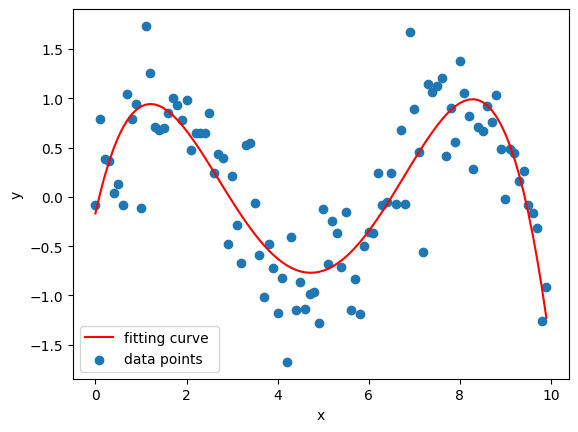

In [3]:
import math
import numpy as np  
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
x_lst = [i/10 for i in range(0,100)]
y_true_lst = []
for i in x_lst:
    #图像修改处
    y_true_lst.append(math.sin(i))


#噪声生成
noise_scale = 0.3
seed = 42  
np.random.seed(seed)  
'''
noise_gaussian = np.random.normal(0, noise_scale, len(x_lst))''
y_gaussian_lst = [y + noise for y, noise in zip(y_true_lst, noise_gaussian)]  高斯噪声
'''
noise_laplace = np.random.laplace(0, noise_scale, len(x_lst))
y_laplace_lst = [y + noise for y, noise in zip(y_true_lst, noise_laplace)]


print("y_true_lst:", y_true_lst)
M=4
N=len(x_lst)
#矩阵设计与求解
X_mat = np.zeros((N, M+1))
for n in range(N):
    for j in range(M+1):
        X_mat[n, j] = x_lst[n] ** j 
T = np.array(y_laplace_lst).reshape(-1, 1)
X_mat_T = X_mat.T  
temp = np.dot(X_mat_T, X_mat) 
temp_inv = np.linalg.inv(temp) 
temp2 = np.dot(temp_inv, X_mat_T)
w_opt = np.dot(temp2, T)

def predfuncx(x):
    return sum(w_opt[i] * (x**i) for i in range(M+1))
Ew = 0
for i in range(N):
    Ew += 0.5 * (y_laplace_lst[i] - predfuncx(x_lst[i])) ** 2

print("最优系数：")
print(w_opt)


#评价：RMS
RMS=np.sqrt(Ew/N)
print("均方根误差：", RMS)

#可视化
y_fit_lstsinOLS = [predfuncx(x) for x in x_lst]
plt.plot(x_lst, y_fit_lstsinOLS, label='fitting curve ', color='red')
plt.scatter(x_lst, y_laplace_lst, label='data points')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()


**PART3.RANSAC拟合直线曲线**

前5个拟合值: [np.float64(1.418205329974155), np.float64(1.4868414937081005), np.float64(1.5727159940963715), np.float64(1.6745213829824923), np.float64(1.7910069185961504)]
前5个带噪声数据点: [np.float64(0.9133272475676982), np.float64(1.8950922751072727), np.float64(1.587079553895651), np.float64(1.6659386119648025), np.float64(1.4506102175113802)]


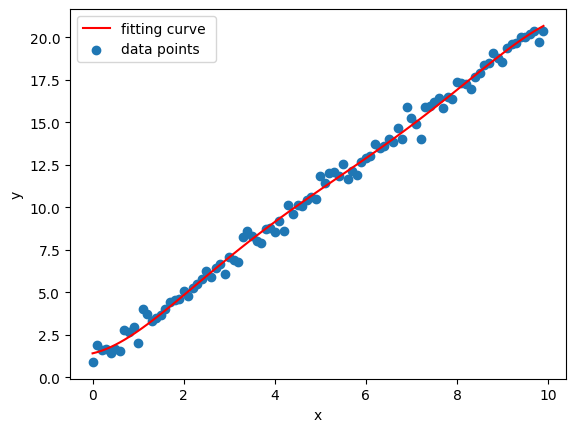

In [4]:
#RANSAC算法
import math
import numpy as np  
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
x_lst = [i/10 for i in range(0,100)]
y_true_lst = []
for i in x_lst:
    #图像修改处
    y_true_lst.append(2*i+1)


#噪声生成
noise_scale = 0.3
seed = 42  
np.random.seed(seed)  
'''
noise_gaussian = np.random.normal(0, noise_scale, len(x_lst))''
y_gaussian_lst = [y + noise for y, noise in zip(y_true_lst, noise_gaussian)]  高斯噪声
'''
noise_laplace = np.random.laplace(0, noise_scale, len(x_lst))
y_laplace_lst = [y + noise for y, noise in zip(y_true_lst, noise_laplace)]



# 转换为numpy数组（适配sklearn接口）
x = np.array(x_lst).reshape(-1, 1)  # 必须是2D数组（样本数×特征数）
y_noisy = np.array(y_laplace_lst)

degree = 5
# 构建RANSAC模型
ransac = make_pipeline(
    PolynomialFeatures(degree=degree),  # 生成多项式特征
    RANSACRegressor(
        min_samples=50,        # 拟合模型所需的最小样本数
        residual_threshold=0.1,# 残差阈值：超过该值的视为异常值（噪声）
        random_state=seed      # 固定随机种子保证结果可复现
    )
)

ransac.fit(x, y_noisy)


# 生成拟合值列表（匹配你指定的列表推导式风格）
y_fit_lst2 = [ransac.predict(np.array([[x_val]]))[0] for x_val in x_lst]

print("前5个拟合值:", y_fit_lst2[:5])
print("前5个带噪声数据点:", y_laplace_lst[:5])

#可视化
plt.plot(x_lst, y_fit_lst2, label='fitting curve ', color='red')
plt.scatter(x_lst, y_laplace_lst, label='data points')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()


前5个拟合值: [np.float64(-1.2035854208032577), np.float64(-0.8195485367528612), np.float64(-0.47956313470194956), np.float64(-0.18091698329158845), np.float64(0.07901234493969267)]
前5个带噪声数据点: [np.float64(-0.08667275243230181), np.float64(0.794925691754101), np.float64(0.38574888469071233), np.float64(0.36145881862614193), np.float64(0.04002855982003073)]


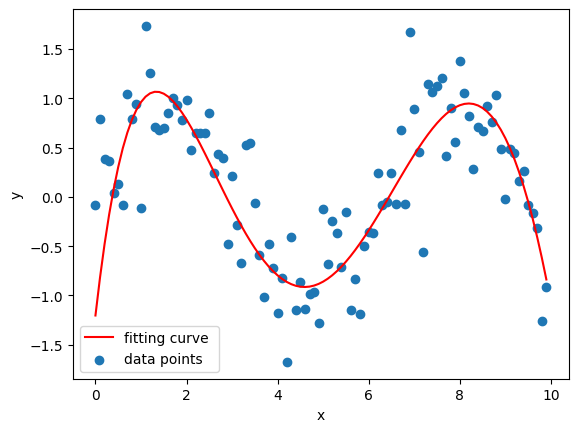

In [5]:
#RANSAC算法
import math
import numpy as np  
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
x_lst = [i/10 for i in range(0,100)]
y_true_lst = []
for i in x_lst:
    #图像修改处
    y_true_lst.append(math.sin(i))


#噪声生成
noise_scale = 0.3
seed = 42  
np.random.seed(seed)  
'''
noise_gaussian = np.random.normal(0, noise_scale, len(x_lst))''
y_gaussian_lst = [y + noise for y, noise in zip(y_true_lst, noise_gaussian)]  高斯噪声
'''
noise_laplace = np.random.laplace(0, noise_scale, len(x_lst))
y_laplace_lst = [y + noise for y, noise in zip(y_true_lst, noise_laplace)]



# 转换为numpy数组（适配sklearn接口）
x = np.array(x_lst).reshape(-1, 1)  # 必须是2D数组（样本数×特征数）
y_noisy = np.array(y_laplace_lst)

degree = 5
# 构建RANSAC模型
ransac = make_pipeline(
    PolynomialFeatures(degree=degree),  # 生成多项式特征
    RANSACRegressor(
        min_samples=50,        # 拟合模型所需的最小样本数
        residual_threshold=0.1,# 残差阈值：超过该值的视为异常值（噪声）
        random_state=seed      # 固定随机种子保证结果可复现
    )
)

ransac.fit(x, y_noisy)


# 生成拟合值列表（匹配你指定的列表推导式风格）
y_fit_lst2sin = [ransac.predict(np.array([[x_val]]))[0] for x_val in x_lst]

print("前5个拟合值:", y_fit_lst2sin[:5])
print("前5个带噪声数据点:", y_laplace_lst[:5])

#可视化
plt.plot(x_lst, y_fit_lst2sin, label='fitting curve ', color='red')
plt.scatter(x_lst, y_laplace_lst, label='data points')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()


**PART3附：圆与椭圆曲线拟合**

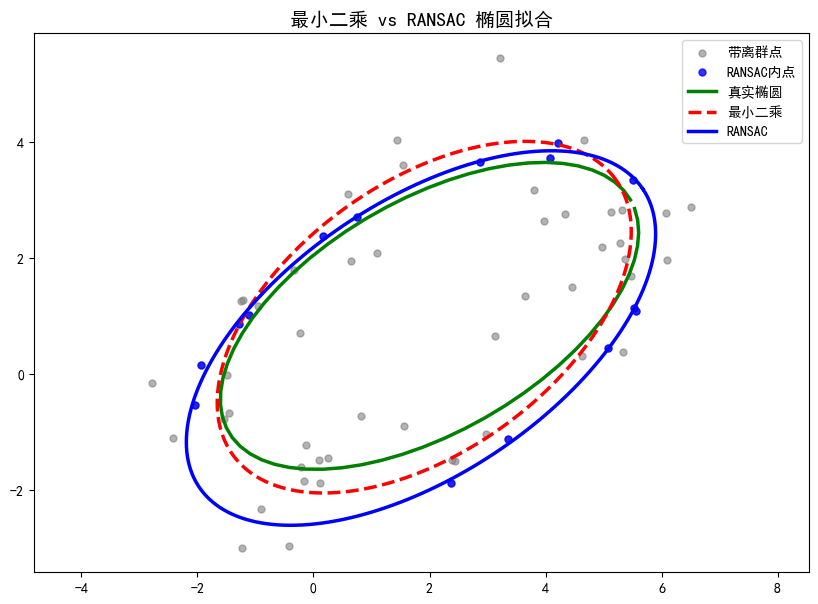

In [6]:
import math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor
from sklearn.base import BaseEstimator, RegressorMixin

# ===================== 1. 生成椭圆数据=====================
theta_lst = [i/10 for i in range(0, 63)]
x_true_lst = []
y_true_lst = []
center_x, center_y = 2, 1
a, b = 4, 2
theta_rot = math.radians(30)

for theta in theta_lst:
    x_ell = a * math.cos(theta)
    y_ell = b * math.sin(theta)
    x = center_x + x_ell * math.cos(theta_rot) - y_ell * math.sin(theta_rot)
    y = center_y + x_ell * math.sin(theta_rot) + y_ell * math.cos(theta_rot)
    x_true_lst.append(x)
    y_true_lst.append(y)

# 加噪声
noise_scale = 0.5
np.random.seed(42)
x = np.array(x_true_lst) + np.random.laplace(0, noise_scale, len(x_true_lst))
y = np.array(y_true_lst) + np.random.laplace(0, noise_scale, len(y_true_lst))


# ===================== 2. 椭圆拟合器（兼容sklearn）=====================
class EllipseFitter(BaseEstimator, RegressorMixin):
    def fit(self, X, y=None):
        x = X[:, 0]
        y = X[:, 1]
        D = np.column_stack([x**2, x*y, y**2, x, y, np.ones_like(x)])
        S = D.T @ D
        C = np.zeros((6,6))
        C[0,2] = C[2,0] = 2
        C[1,1] = -1
        vals, vecs = np.linalg.eig(np.linalg.inv(S) @ C)
        self.coef_ = vecs[:, np.argmax(vals>0)]
        return self
    
    def predict(self, X):
        x, y = X[:,0], X[:,1]
        A,B,C,D,E,F = self.coef_
        return A*x**2 + B*x*y + C*y**2 + D*x + E*y + F

# ===================== 3. 最小二乘 + RANSAC =====================
X = np.column_stack([x, y])
y_dummy = np.zeros(len(X))  

# 最小二乘
ls = EllipseFitter()
ls.fit(X)

# RANSAC
ransac = RANSACRegressor(estimator=EllipseFitter(), 
                         min_samples=10, residual_threshold=0.1, random_state=42)
ransac.fit(X, y_dummy)  
inlier_mask = ransac.inlier_mask_

# ===================== 4. 椭圆参数转绘图 =====================
def ellipse_points(coef, n=200):
    A,B,C,D,E,F = coef
    den = B**2 - 4*A*C
    cx = (2*C*D - B*E)/den
    cy = (2*A*E - B*D)/den
    ang = 0.5 * np.arctan2(B, A-C)
    t = np.linspace(0, 2*np.pi, n)
    ct, st = np.cos(t), np.sin(t)
    ca, sa = np.cos(ang), np.sin(ang)
    up = A*cx**2 + B*cx*cy + C*cy**2 - F
    a = np.sqrt(2*up / ((A+C)+np.sqrt((A-C)**2+B**2)))
    b = np.sqrt(2*up / ((A+C)-np.sqrt((A-C)**2+B**2)))
    xs = cx + a*ct*ca - b*st*sa
    ys = cy + a*ct*sa + b*st*ca
    return xs, ys

x1, y1 = ellipse_points(ls.coef_)
x2, y2 = ellipse_points(ransac.estimator_.coef_)

# ===================== 5. 画图 =====================
plt.rcParams['font.sans-serif'] = ['SimHei']  # 支持中文显示
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题
plt.figure(figsize=(10,7))
plt.scatter(x, y, c='gray', s=25, alpha=0.6, label='带离群点')
plt.scatter(x[inlier_mask], y[inlier_mask], c='blue', s=25, alpha=0.8, label='RANSAC内点')
plt.plot(x_true_lst, y_true_lst, 'g-', lw=2.5, label='真实椭圆')
plt.plot(x1, y1, 'r--', lw=2.5, label='最小二乘')
plt.plot(x2, y2, 'b-', lw=2.5, label='RANSAC')
plt.axis('equal')
plt.legend()
plt.title('最小二乘 vs RANSAC 椭圆拟合', fontsize=14)
plt.show()

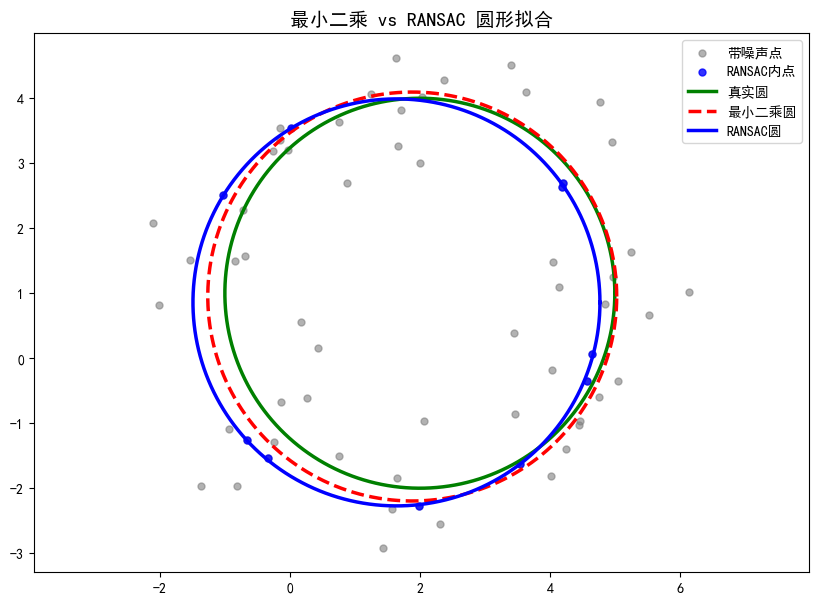

In [7]:
import math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor
from sklearn.base import BaseEstimator, RegressorMixin

# ===================== 1. 生成圆形数据 =====================
theta_lst = [i/10 for i in range(0, 63)]
x_true_lst = []
y_true_lst = []
center_x, center_y = 2, 1
r = 3  # 圆半径

for theta in theta_lst:
    x = center_x + r * math.cos(theta)
    y = center_y + r * math.sin(theta)
    x_true_lst.append(x)
    y_true_lst.append(y)

# 加噪声
noise_scale = 0.5
np.random.seed(42)
x = np.array(x_true_lst) + np.random.laplace(0, noise_scale, len(x_true_lst))
y = np.array(y_true_lst) + np.random.laplace(0, noise_scale, len(y_true_lst))

# ===================== 2. 圆拟合器（CircleFitter）=====================
class CircleFitter(BaseEstimator, RegressorMixin):
    def fit(self, X, y=None):
        x = X[:, 0]
        y = X[:, 1]
        
        # 圆的代数方程：x² + y² + Dx + Ey + F = 0
        # 构建最小二乘矩阵
        A = np.column_stack([x, y, np.ones_like(x)])
        B = -(x**2 + y**2)
        
        # 最小二乘求解 D, E, F
        D, E, F = np.linalg.lstsq(A, B, rcond=None)[0]
        
        # 圆心与半径
        cx = -D / 2
        cy = -E / 2
        radius = np.sqrt(cx**2 + cy**2 - F)
        
        self.cx_ = cx
        self.cy_ = cy
        self.radius_ = radius
        self.coef_ = (D, E, F)
        return self
    
    def predict(self, X):
        x, y = X[:, 0], X[:, 1]
        D, E, F = self.coef_
        return x**2 + y**2 + D*x + E*y + F

# ===================== 3. 最小二乘 + RANSAC =====================
X = np.column_stack([x, y])
y_dummy = np.zeros(len(X))  

# 最小二乘圆拟合
ls_circle = CircleFitter()
ls_circle.fit(X)

# RANSAC 圆拟合
ransac_circle = RANSACRegressor(
    estimator=CircleFitter(), 
    min_samples=3,        # 圆只需要3个点
    residual_threshold=0.3, 
    random_state=42
)
ransac_circle.fit(X, y_dummy)
inlier_mask = ransac_circle.inlier_mask_

# ===================== 4. 生成圆的绘图点 =====================
def circle_points(cx, cy, r, n=200):
    t = np.linspace(0, 2*np.pi, n)
    xs = cx + r * np.cos(t)
    ys = cy + r * np.sin(t)
    return xs, ys

# 生成曲线
x_true, y_true = circle_points(center_x, center_y, r)
x1, y1 = circle_points(ls_circle.cx_, ls_circle.cy_, ls_circle.radius_)
x2, y2 = circle_points(
    ransac_circle.estimator_.cx_,
    ransac_circle.estimator_.cy_,
    ransac_circle.estimator_.radius_
)

# ===================== 5. 画图 =====================
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(10,7))
plt.scatter(x, y, c='gray', s=25, alpha=0.6, label='带噪声点')
plt.scatter(x[inlier_mask], y[inlier_mask], c='blue', s=25, alpha=0.8, label='RANSAC内点')
plt.plot(x_true, y_true, 'g-', lw=2.5, label='真实圆')
plt.plot(x1, y1, 'r--', lw=2.5, label='最小二乘圆')
plt.plot(x2, y2, 'b-', lw=2.5, label='RANSAC圆')
plt.axis('equal')
plt.legend()
plt.title('最小二乘 vs RANSAC 圆形拟合', fontsize=14)
plt.show()

**PART4.三条平行直线拟合**

原直线0斜截式: y = -0.667 * x + 1.667
原直线1斜截式: y = -0.667 * x 
原直线2斜截式: y = -0.667 * x - 1.667
============================== OLS 拟合结果 ==============================
真实 a=2.000
真实 b=3.000, OLS拟合斜率k=-0.778
直线 0: 真实 c=-5.000, OLS拟合截距d=1.911
直线 1: 真实 c=0.000, OLS拟合截距d=-0.356
直线 2: 真实 c=5.000, OLS拟合截距d=-1.289

============================== RANSAC 拟合结果 ==============================
真实 a=2.000, RANSAC拟合 a=2.135
真实 b=3.000, RANSAC拟合 b=3.000
直线 0: 真实 c=-5.000, RANSAC拟合 c=-4.907
直线 1: 真实 c=0.000, RANSAC拟合 c=-0.020
直线 2: 真实 c=5.000, RANSAC拟合 c=4.942


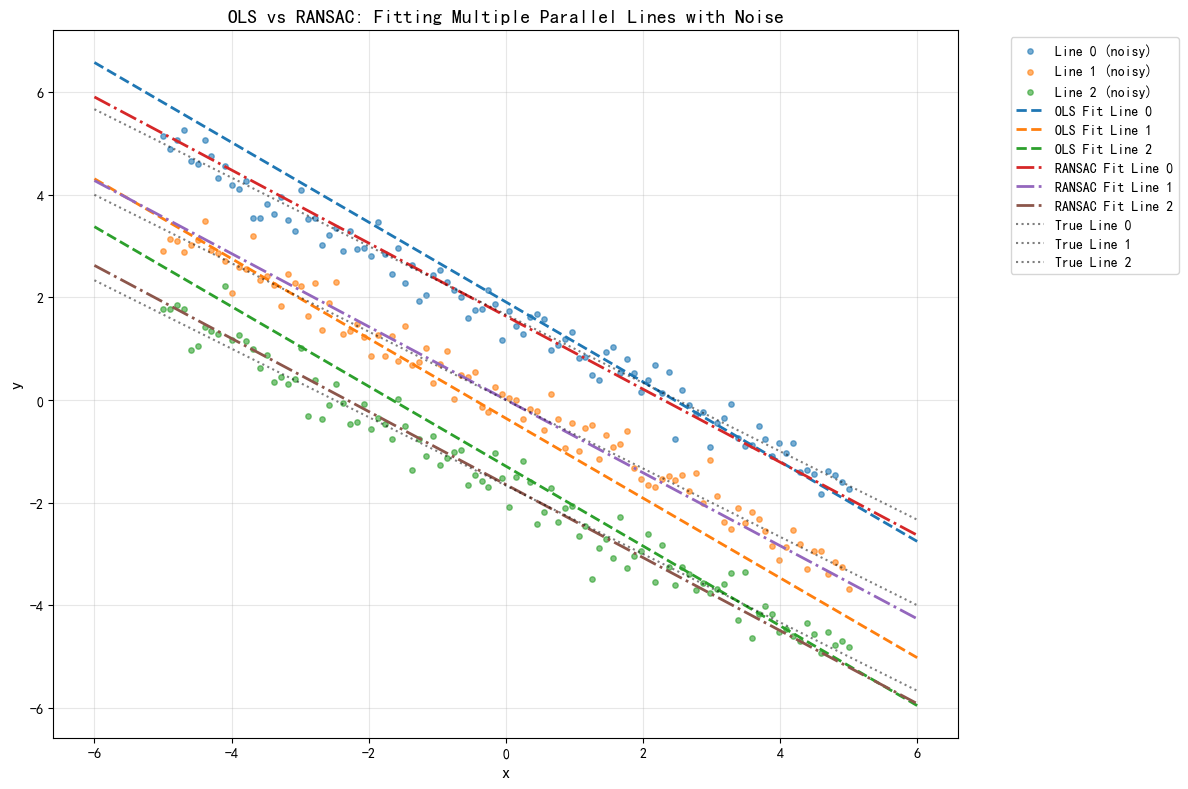

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from sklearn.linear_model import RANSACRegressor


np.random.seed(42)

# 平行直线的共同方向：a x + b y + c_i = 0
a_true = 2.0
b_true = 3.0
c_list_true = [-5.0, 0.0, 5.0]  # 三条平行直线的截距参数
n_points_per_line = 100     # 每条直线上的点数
noise_scale = 0.3           # 噪声强度

print("原直线0斜截式: y = -0.667 * x + 1.667")
print("原直线1斜截式: y = -0.667 * x ")
print("原直线2斜截式: y = -0.667 * x - 1.667")
# 存储所有数据
x_all = []
y_all = []
line_labels = []

for idx, c in enumerate(c_list_true):
    # 生成直线上的点：a x + b y + c = 0 → y = -(a x + c)/b
    x_line = np.linspace(-5, 5, n_points_per_line)
    y_true_line = -(a_true * x_line + c) / b_true
    
    # 加噪声（沿垂直于直线方向的噪声更合理）
    y_noisy_line = y_true_line + np.random.normal(0, noise_scale, size=n_points_per_line)
    
    x_all.extend(x_line)
    y_all.extend(y_noisy_line)
    line_labels.extend([idx] * n_points_per_line)

x_all = np.array(x_all).reshape(-1, 1)  # 适配sklearn接口
y_all = np.array(y_all)
line_labels = np.array(line_labels)

def residual(params, x, y, line_labels):
    """残差函数：a x + b y + c_i"""
    a_fit, b_fit = params[0], params[1]
    c_fit_list = params[2:]
    res = []
    for i in range(len(x)):
        c_i = c_fit_list[line_labels[i]]
        res.append(a_fit * x[i, 0] + b_fit * y[i] + c_i)  # x是2D数组，取x[i,0]
    return np.array(res)

print("="*30 + " OLS 拟合结果 " + "="*30)

x0_ols = [a_true, b_true] + c_list_true
# 最小二乘拟合（OLS）
result_ols = least_squares(residual, x0_ols, args=(x_all, y_all, line_labels))
a_ols, b_ols = result_ols.x[0], result_ols.x[1]
c_list_ols = result_ols.x[2:]

# 输出OLS结果
print(f"真实 a={a_true:.3f}")
print(f"真实 b={b_true:.3f}, OLS拟合斜率k={-a_ols/b_ols:.3f}")
for i, (c_true, c_ols) in enumerate(zip(c_list_true, c_list_ols)):
    print(f"直线 {i}: 真实 c={c_true:.3f}, OLS拟合截距d={-c_ols/b_ols:.3f}")

# ===================== 4. RANSAC 拟合（分两步：先拟合公共方向a,b，再拟合各c_i） =====================
print("\n" + "="*30 + " RANSAC 拟合结果 " + "="*30)

# 步骤1：用RANSAC拟合公共方向（a,b）
# 转换模型：a x + b y + c = 0 → y = (-a/b)x - c/b → 斜率k=-a/b，截距d=-c/b
# 先合并所有点，拟合公共斜率k（因为平行直线斜率相同）
def line_model(x, k, d):
    """直线模型：y = k*x + d"""
    return k * x + d

# 用RANSAC拟合整体斜率（公共方向）
ransac_global = RANSACRegressor(random_state=42)
ransac_global.fit(x_all, y_all)
k_ransac = ransac_global.estimator_.coef_[0]  # 斜率k=-a/b
d_ransac_temp = ransac_global.estimator_.intercept_  # 临时截距

# 从斜率反推a,b（保持a和b的比例与真实值一致，仅调整幅值）
a_ransac = -k_ransac * b_true  # k=-a/b → a=-k*b
b_ransac = b_true  # 固定b，仅拟合a（保证方向一致）

# 步骤2：对每条直线，用RANSAC拟合截距c_i
c_list_ransac = []
for idx in range(len(c_list_true)):
    # 提取当前直线的点
    mask = (line_labels == idx)
    x_line = x_all[mask]
    y_line = y_all[mask]
    
    # 拟合当前直线的截距：a*x + b*y + c = 0 → c = -(a*x + b*y)
    def residual_c(c, x, y, a, b):
        return a * x[:, 0] + b * y + c  # 残差：a*x + b*y + c
    
    # 初始猜测c
    c0 = -(a_ransac * np.mean(x_line) + b_ransac * np.mean(y_line))
    # 用最小二乘拟合c（基于RANSAC得到的a,b）
    result_c = least_squares(residual_c, c0, args=(x_line, y_line, a_ransac, b_ransac))
    c_ransac = result_c.x[0]
    c_list_ransac.append(c_ransac)

# 输出RANSAC结果
print(f"真实 a={a_true:.3f}, RANSAC拟合 a={a_ransac:.3f}")
print(f"真实 b={b_true:.3f}, RANSAC拟合 b={b_ransac:.3f}")
for i, (c_true, c_ransac) in enumerate(zip(c_list_true, c_list_ransac)):
    print(f"直线 {i}: 真实 c={c_true:.3f}, RANSAC拟合 c={c_ransac:.3f}")

# ===================== 5. 可视化对比 =====================
plt.figure(figsize=(12, 8))

# 绘制带噪声的原始点
for idx in range(len(c_list_true)):
    mask = (line_labels == idx)
    plt.scatter(x_all[mask, 0], y_all[mask], s=15, alpha=0.6, label=f'Line {idx} (noisy)')

# 绘制OLS拟合的直线
x_plot = np.linspace(-6, 6, 100)
for i, c_ols in enumerate(c_list_ols):
    y_ols_line = -(a_ols * x_plot + c_ols) / b_ols
    plt.plot(x_plot, y_ols_line, '--', linewidth=2, label=f'OLS Fit Line {i}')

# 绘制RANSAC拟合的直线
for i, c_ransac in enumerate(c_list_ransac):
    y_ransac_line = -(a_ransac * x_plot + c_ransac) / b_ransac
    plt.plot(x_plot, y_ransac_line, '-.', linewidth=2, label=f'RANSAC Fit Line {i}')

# 绘制真实直线（参考）
for i, c_true in enumerate(c_list_true):
    y_true_line = -(a_true * x_plot + c_true) / b_true
    plt.plot(x_plot, y_true_line, ':', linewidth=1.5, color='black', alpha=0.5, label=f'True Line {i}')

plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('OLS vs RANSAC: Fitting Multiple Parallel Lines with Noise', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**PART5.引入正则化的最小二乘拟合**

最优系数：
[[-5.91895654e+00]
 [ 3.16540111e+00]
 [ 3.66743187e+00]
 [-5.32742032e+00]
 [ 2.90624866e+00]
 [-6.48202949e-01]
 [-8.86347216e-02]
 [ 9.10231162e-02]
 [-2.28328711e-02]
 [ 2.46289684e-03]
 [-2.43635460e-05]
 [-1.92168383e-05]
 [ 1.49289483e-06]
 [-6.11812115e-08]
 [ 1.44967237e-08]
 [-2.05807246e-09]
 [ 1.17322129e-10]
 [-2.41099101e-12]]
均方根误差： [1.20308168]


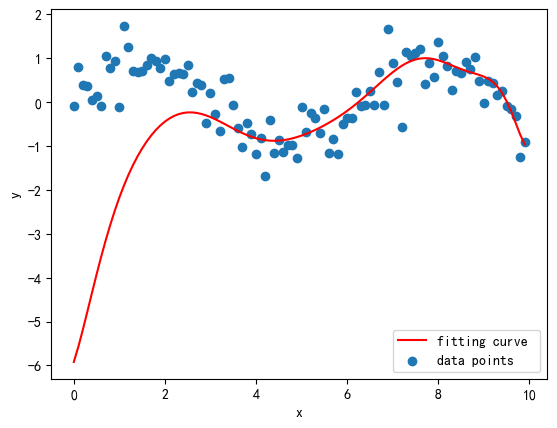

In [9]:
#最小二乘法过拟合
import math
import numpy as np  
import matplotlib.pyplot as plt

x_lst = [i/10 for i in range(0,100)]
y_true_lst = []
for i in x_lst:
    #图像修改处
    y_true_lst.append(math.sin(i))


#噪声生成
noise_scale = 0.3
seed = 42  
np.random.seed(seed)  
'''
noise_gaussian = np.random.normal(0, noise_scale, len(x_lst))''
y_gaussian_lst = [y + noise for y, noise in zip(y_true_lst, noise_gaussian)]  高斯噪声
'''
noise_laplace = np.random.laplace(0, noise_scale, len(x_lst))
y_laplace_lst = [y + noise for y, noise in zip(y_true_lst, noise_laplace)]


M=17

N=len(x_lst)
#矩阵设计与求解
X_mat = np.zeros((N, M+1))
for n in range(N):
    for j in range(M+1):
        X_mat[n, j] = x_lst[n] ** j 
T = np.array(y_laplace_lst).reshape(-1, 1)
X_mat_T = X_mat.T  
temp = np.dot(X_mat_T, X_mat) 
temp_inv = np.linalg.inv(temp) 
temp2 = np.dot(temp_inv, X_mat_T)
w_opt = np.dot(temp2, T)

def predfuncx(x):
    return sum(w_opt[i] * (x**i) for i in range(M+1))
Ew = 0
for i in range(N):
    Ew += 0.5 * (y_laplace_lst[i] - predfuncx(x_lst[i])) ** 2

print("最优系数：")
print(w_opt)


#评价：RMS
RMS=np.sqrt(Ew/N)
print("均方根误差：", RMS)

#可视化
y_fit_lst = [predfuncx(x) for x in x_lst]
plt.plot(x_lst, y_fit_lst, label='fitting curve ', color='red')
plt.scatter(x_lst, y_laplace_lst, label='data points')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()


L2正则化后的最优系数： [[ 1.99086757e-01]
 [ 3.66007418e-01]
 [ 2.98243860e-01]
 [-5.13103350e-02]
 [-1.44613530e-01]
 [ 9.13487266e-02]
 [-4.92246173e-02]
 [ 2.14303836e-02]
 [-5.55395868e-03]
 [ 7.49763739e-04]
 [-2.77854849e-05]
 [-6.75594013e-06]
 [ 1.19834557e-06]
 [-8.25678875e-08]
 [ 2.15622389e-10]
 [ 4.51800699e-10]
 [-3.50507133e-11]
 [ 9.08070700e-13]]
均方根误差： [0.27870498]
正则化后的总损失 Ewlam2 = [7.76764682]


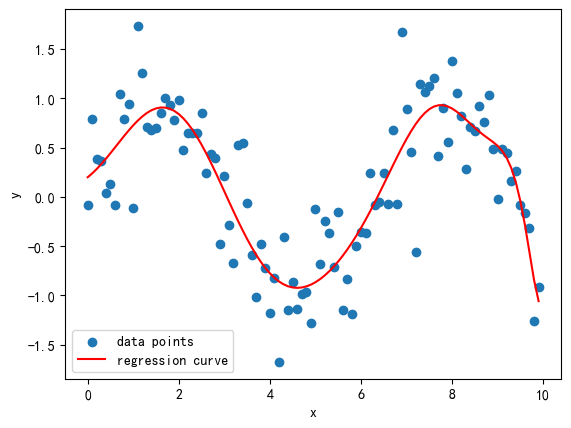

In [10]:
#L2正则化
import math
import numpy as np  
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
x_lst = [i/10 for i in range(0,100)]
y_true_lst = []
for i in x_lst:
    #图像修改处
    y_true_lst.append(math.sin(i))


#噪声生成
noise_scale = 0.3
seed = 42  
np.random.seed(seed)  
'''
noise_gaussian = np.random.normal(0, noise_scale, len(x_lst))''
y_gaussian_lst = [y + noise for y, noise in zip(y_true_lst, noise_gaussian)]  高斯噪声
'''
noise_laplace = np.random.laplace(0, noise_scale, len(x_lst))
y_laplace_lst = [y + noise for y, noise in zip(y_true_lst, noise_laplace)]

lambdax=0.1
M=17
N=len(x_lst)
fanshu2=0
qqqqq=0
'''
目标函数
for i in range(N):
    Ew += 0.5 * (y_laplace_lst[i] - predfuncx(x_lst[i])) ** 2
for i in range(M+1):
    qqqqq+=w_opt[i]**2
Ewlam2=Ew+lambdax/2*qqqqq
'''
#矩阵搭建与求解
X_mat = np.zeros((N, M+1))
for n in range(N):
    for j in range(M+1):
        X_mat[n, j] = x_lst[n] ** j
t = np.array(y_laplace_lst).reshape(-1, 1)
X_mat_T = X_mat.T
A = X_mat_T @ X_mat + lambdax * np.eye(M+1) 
b = X_mat_T @ t
w_opt_reg = np.linalg.solve(A, b)  


def predfuncx_reg(x):
    return sum(w_opt_reg[i] * (x ** i) for i in range(M+1))

Ew = 0
for i in range(N):
    Ew += 0.5 * (y_laplace_lst[i] - predfuncx_reg(x_lst[i])) ** 2

w_sq_sum = sum(w_opt_reg[i] ** 2 for i in range(M+1))
Ewlam2 = Ew + (lambdax / 2) * w_sq_sum

print("L2正则化后的最优系数：", w_opt_reg)
#评价：RMS
RMS=np.sqrt(Ewlam2/N)
print("均方根误差：", RMS)
print("正则化后的总损失 Ewlam2 =", Ewlam2)

#PART4 可视化-------------------------------------------------------------------------------------------------
y_fit_lstzz= [predfuncx_reg(x) for x in x_lst]
plt.scatter(x_lst, y_laplace_lst, label='data points')
plt.plot(x_lst, y_fit_lstzz, label='regression curve', color='red') 
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()



L1正则化后的最优系数： [[ 2.52548534e-04]
 [ 1.31102446e+00]
 [-5.37430483e-01]
 [ 3.51723952e-03]
 [ 1.02038967e-02]
 [ 1.12501031e-04]
 [-4.00967069e-05]
 [-4.84841761e-06]
 [-3.34207541e-07]
 [-1.15688701e-08]
 [ 7.63852008e-10]
 [ 2.01329867e-10]
 [ 2.50065423e-11]
 [ 2.29367537e-12]
 [ 1.52494908e-13]
 [ 3.41580700e-15]
 [-1.11927698e-15]
 [-2.74055745e-16]]
均方根误差(RMS)： [0.2841637]
L1正则化后的总损失 Ewlam1 = [8.09352673]


d:\python\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.937e+00, tolerance: 5.867e-07
  model = cd_fast.enet_coordinate_descent(


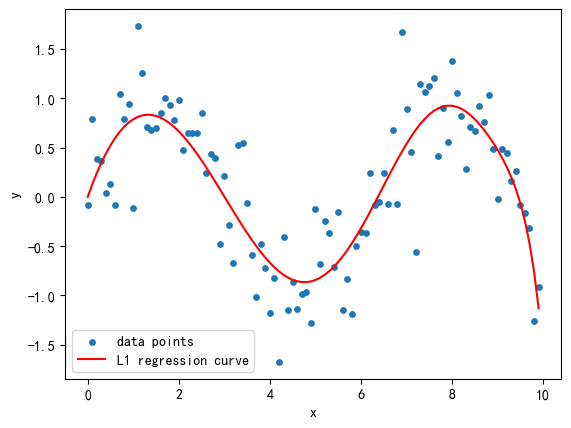

In [11]:
#L1正则化 
import math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso  

# 1. 生成数据
x_lst = [i/10 for i in range(0,100)]
y_true_lst = [math.sin(i) for i in x_lst]

# 2. 生成拉普拉斯噪声
noise_scale = 0.3
seed = 42
np.random.seed(seed)
noise_laplace = np.random.laplace(0, noise_scale, len(x_lst))
y_laplace_lst = [y + noise for y, noise in zip(y_true_lst, noise_laplace)]

# 3. L1正则化核心参数
alpha = 0.01  # L1正则化系数（等价于原代码的lambdax）
M = 17        # 多项式阶数

# 4. 构造多项式特征矩阵
N = len(x_lst)
X_mat = np.zeros((N, M+1))
for n in range(N):
    for j in range(M+1):
        X_mat[n, j] = x_lst[n] ** j

# 5. L1正则化求解（Lasso）
# L1无闭式解，使用sklearn的Lasso迭代求解
lasso = Lasso(alpha=alpha, max_iter=100000, tol=1e-8, fit_intercept=False)
lasso.fit(X_mat, y_laplace_lst)
w_opt_reg = lasso.coef_.reshape(-1, 1)  # L1正则化最优权重

# 6. 定义预测函数
def predfuncx_reg(x):
    return sum(w_opt_reg[i] * (x ** i) for i in range(M+1))

# 7. 计算损失函数（L1正则化目标函数）
EwL = 0  # 经验损失（均方误差）
for i in range(N):
    EwL += 0.5 * (y_laplace_lst[i] - predfuncx_reg(x_lst[i])) ** 2

w_abs_sum = sum(abs(w_opt_reg[i]) for i in range(M+1))  # L1：权重绝对值和
Ewlam1 = EwL + alpha * w_abs_sum  # L1总损失 = 误差 + 正则项

# 8. 评价指标
RMS = np.sqrt(EwL / N)
print("L1正则化后的最优系数：", w_opt_reg)
print("均方根误差(RMS)：", RMS)
print("L1正则化后的总损失 Ewlam1 =", Ewlam1)

# 9. 可视化
y_fit_lstzz1 = [predfuncx_reg(x) for x in x_lst]
plt.scatter(x_lst, y_laplace_lst, label='data points', s=15)
plt.plot(x_lst, y_fit_lstzz1, label='L1 regression curve', color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

**PART6.MLP拟合**


开始训练MLP...
Epoch    0 | Loss: 0.686042
Epoch  300 | Loss: 0.151151
Epoch  600 | Loss: 0.139491
Epoch  900 | Loss: 0.131165
MLP 神经网络 RMS:    0.25325731904138854


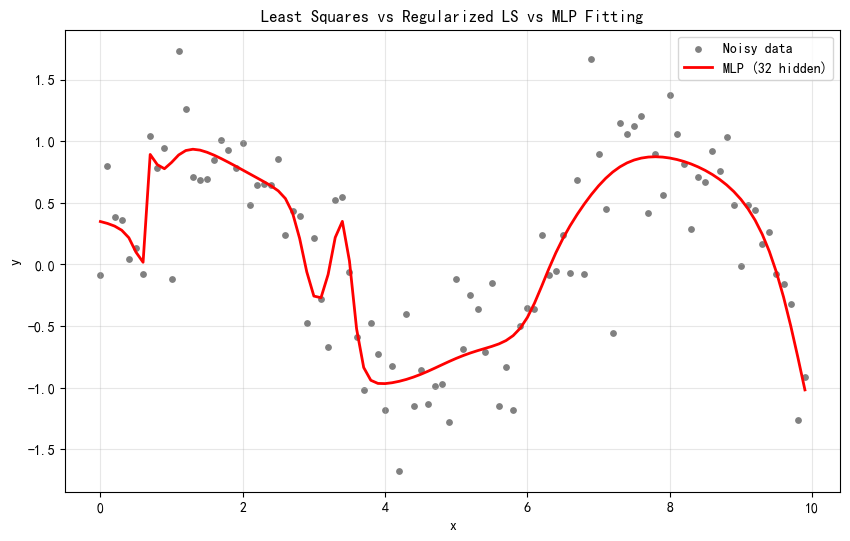

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import math
import numpy as np  
import matplotlib.pyplot as plt

x_lst = [i/10 for i in range(0,100)]
y_true_lst = []
for i in x_lst:
    #图像修改处
    y_true_lst.append(math.sin(i))


#噪声生成
noise_scale = 0.3
seed = 42  
np.random.seed(seed)  
'''
noise_gaussian = np.random.normal(0, noise_scale, len(x_lst))''
y_gaussian_lst = [y + noise for y, noise in zip(y_true_lst, noise_gaussian)]  高斯噪声
'''
#M=4
#N=len(x_lst)
noise_laplace = np.random.laplace(0, noise_scale, len(x_lst))
y_laplace_lst = [y + noise for y, noise in zip(y_true_lst, noise_laplace)]
# 1. 数据转张量
x = torch.tensor(x_lst, dtype=torch.float32).unsqueeze(1)  # [101,1]
y = torch.tensor(y_laplace_lst, dtype=torch.float32).unsqueeze(1)

# 2. 定义极简MLP：输入1维 → 隐藏层32 → 输出1维
class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32),
            nn.Tanh(),
            nn.Linear(32, 16), 
            nn.Tanh(),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.net(x)

# 3. 训练配置
model = SimpleMLP()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
epochs = 1000
# 4. 训练
print("\n开始训练MLP...")
for epoch in range(epochs):
    optimizer.zero_grad()
    pred = model(x)
    loss = criterion(pred, y)
    loss.backward()
    optimizer.step()
    if epoch % 300 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss.item():.6f}")

# 5. MLP预测结果
with torch.no_grad():
    y_mlp_lst = model(x).squeeze().numpy()

# 6. 计算MLP的RMS
Ew_mlp = 0.5 * np.sum((y_laplace_lst - y_mlp_lst) ** 2)
RMS_MLP = np.sqrt(Ew_mlp / len(x_lst))
print("MLP 神经网络 RMS:   ", RMS_MLP)

# ===================== 统一可视化对比 =====================
plt.figure(figsize=(10,6))
plt.scatter(x_lst, y_laplace_lst, c='gray', s=15, label='Noisy data')
plt.plot(x_lst, y_mlp_lst, 'r-', linewidth=2, label='MLP (32 hidden)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Least Squares vs Regularized LS vs MLP Fitting')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**PART7.综合对比与引入外点后分析**(以y=sinx为例)

d:\python\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.878e+00, tolerance: 5.867e-07
  model = cd_fast.enet_coordinate_descent(



开始训练MLP...
Epoch    0 | Loss: 0.538372
Epoch  300 | Loss: 0.163708
Epoch  600 | Loss: 0.144186
Epoch  900 | Loss: 0.131743
OLS均方根误差： [0.29727164]
OLS+L2均方根误差： [0.30201649]
OLS+L1均方根误差(RMS)： [0.30131553]
MLP 神经网络 RMS:    0.25413657083970986


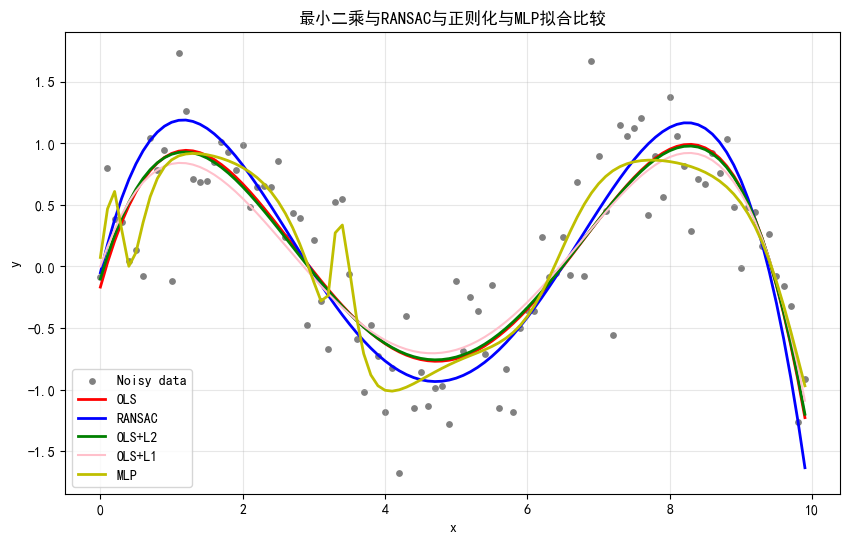

In [13]:
#未引入外点
import math
import numpy as np  
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
import torch
import torch.nn as nn
import torch.optim as optim
x_lst = [i/10 for i in range(0,100)]
y_true_lst = []
for i in x_lst:
    #图像修改处
    y_true_lst.append(math.sin(i))
#噪声生成
noise_scale = 0.3
seed = 42  
np.random.seed(seed)  
noise_laplace = np.random.laplace(0, noise_scale, len(x_lst))
y_laplace_lst = [y + noise for y, noise in zip(y_true_lst, noise_laplace)]
#


#最小二乘法----------------------------------------------------
M=4
N=len(x_lst)
#矩阵设计与求解
X_mat1 = np.zeros((N, M+1))
for n in range(N):
    for j in range(M+1):
        X_mat1[n, j] = x_lst[n] ** j 
T = np.array(y_laplace_lst).reshape(-1, 1)
X_mat_T1 = X_mat1.T  
temp = np.dot(X_mat_T1, X_mat1) 
temp_inv = np.linalg.inv(temp) 
temp2 = np.dot(temp_inv, X_mat_T1)
w_opt = np.dot(temp2, T)

def predfuncxOLS(x):
    return sum(w_opt[i] * (x**i) for i in range(M+1))
Ew = 0
for i in range(N):
    Ew += 0.5 * (y_laplace_lst[i] - predfuncxOLS(x_lst[i])) ** 2

#RANSAC--------------------------------------------------------
# 转换为numpy数组（适配sklearn接口）
xRAN = np.array(x_lst).reshape(-1, 1)  # 必须是2D数组（样本数×特征数）
y_noisyRAN = np.array(y_laplace_lst)

degree = 4
# 构建RANSAC模型
ransac = make_pipeline(
    PolynomialFeatures(degree=degree),  # 生成多项式特征
    RANSACRegressor(
        min_samples=50,        # 拟合模型所需的最小样本数
        residual_threshold=0.1,# 残差阈值：超过该值的视为异常值（噪声）
        random_state=seed      # 固定随机种子保证结果可复现
    )
)

ransac.fit(xRAN, y_noisyRAN)

#L2正则化-----------------------------------------------------------------
lambdax=0.1
fanshu2=0
qqqqq=0

X_mat2 = np.zeros((N, M+1))
for n in range(N):
    for j in range(M+1):
        X_mat2[n, j] = x_lst[n] ** j
t = np.array(y_laplace_lst).reshape(-1, 1)
X_mat_T2 = X_mat2.T
A = X_mat_T2 @ X_mat2 + lambdax * np.eye(M+1) 
b = X_mat_T2 @ t
w_opt_reg = np.linalg.solve(A, b)  


def predfuncx_reg(x):
    return sum(w_opt_reg[i] * (x ** i) for i in range(M+1))

Ew2 = 0
for i in range(N):
    Ew2 += 0.5 * (y_laplace_lst[i] - predfuncx_reg(x_lst[i])) ** 2

w_sq_sum = sum(w_opt_reg[i] ** 2 for i in range(M+1))
Ewlam2 = Ew2 + (lambdax / 2) * w_sq_sum

#L1正则化---------------------------------------------------------------------
alpha = 0.01  # L1正则化系数（等价于原代码的lambdax）
X_matl1 = np.zeros((N, M+1))
for n in range(N):
    for j in range(M+1):
        X_matl1[n, j] = x_lst[n] ** j

lasso = Lasso(alpha=alpha, max_iter=100000, tol=1e-8, fit_intercept=False)
lasso.fit(X_matl1, y_laplace_lst)
w_opt_reg1 = lasso.coef_.reshape(-1, 1)  # L1正则化最优权重

def predfuncx_regl1(x):
    return sum(w_opt_reg1[i] * (x ** i) for i in range(M+1))

# 7. 计算损失函数（L1正则化目标函数）
EwL = 0  # 经验损失（均方误差）
for i in range(N):
    EwL += 0.5 * (y_laplace_lst[i] - predfuncx_regl1(x_lst[i])) ** 2

w_abs_sum = sum(abs(w_opt_reg[i]) for i in range(M+1))  # L1：权重绝对值和
Ewlam1 = EwL + alpha * w_abs_sum  # L1总损失 = 误差 + 正则项

# 8. 评价指标
l1RMS = np.sqrt(EwL / N)




#MLP-------------------------------------------------------------------------

# 1. 数据转张量
xmlp = torch.tensor(x_lst, dtype=torch.float32).unsqueeze(1)  # [101,1]
ymlp = torch.tensor(y_laplace_lst, dtype=torch.float32).unsqueeze(1)

# 2. 定义极简MLP：输入1维 → 隐藏层32 → 输出1维
class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32),
            nn.Tanh(),
            nn.Linear(32, 16), 
            nn.Tanh(),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.net(x)

# 3. 训练配置
model = SimpleMLP()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
epochs = 1000
# 4. 训练
print("\n开始训练MLP...")
for epoch in range(epochs):
    optimizer.zero_grad()
    pred = model(xmlp)
    loss = criterion(pred, ymlp)
    loss.backward()
    optimizer.step()
    if epoch % 300 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss.item():.6f}")

# 5. MLP预测结果
with torch.no_grad():
    y_mlp_lst = model(xmlp).squeeze().numpy()


#评价：RMS
OLSRMS=np.sqrt(Ew/N)
print("OLS均方根误差：", OLSRMS)
OLSzzRMS=np.sqrt(Ewlam2/N)
print("OLS+L2均方根误差：", OLSzzRMS)
Ew_mlp = 0.5 * np.sum((y_laplace_lst - y_mlp_lst) ** 2)
print("OLS+L1均方根误差(RMS)：", l1RMS)
RMS_MLP = np.sqrt(Ew_mlp / len(x_lst))
print("MLP 神经网络 RMS:   ", RMS_MLP)


#可视化
y_fit_lstsinOLS = [predfuncxOLS(x) for x in x_lst]
y_fit_lst2sin = [ransac.predict(np.array([[x_val]]))[0] for x_val in x_lst]
y_fit_lstzz= [predfuncx_reg(x) for x in x_lst]
y_fit_lstzz1 = [predfuncx_regl1(x) for x in x_lst]
y_mlp=y_mlp_lst
plt.rcParams['font.sans-serif'] = ['SimHei']  # 支持中文显示
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题
plt.figure(figsize=(10,6))
plt.scatter(x_lst, y_laplace_lst, c='gray', s=15, label='Noisy data')
plt.plot(x_lst, y_fit_lstsinOLS, 'r-', linewidth=2, label='OLS')
plt.plot(x_lst, y_fit_lst2sin, 'b-', linewidth=2, label='RANSAC')
plt.plot(x_lst, y_fit_lstzz, 'g-', linewidth=2, label='OLS+L2')
plt.plot(x_lst, y_fit_lstzz1, label='OLS+L1', color='pink')
plt.plot(x_lst, y_mlp, 'y-', linewidth=2, label='MLP')
plt.xlabel('x')
plt.ylabel('y')
plt.title('最小二乘与RANSAC与正则化与MLP拟合比较')
plt.legend()
plt.grid(alpha=0.3)
plt.show()



d:\python\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.822e+00, tolerance: 3.352e-06
  model = cd_fast.enet_coordinate_descent(



开始训练MLP...
Epoch    0 | Loss: 3.323865
Epoch  300 | Loss: 2.241937
Epoch  600 | Loss: 2.061202
Epoch  900 | Loss: 1.739335
OLS均方根误差： [1.02567499]
OLS+L2均方根误差： [1.05873295]
OLS+L1均方根误差(RMS)： [1.02918728]
MLP 神经网络 RMS:    0.9250337170989638


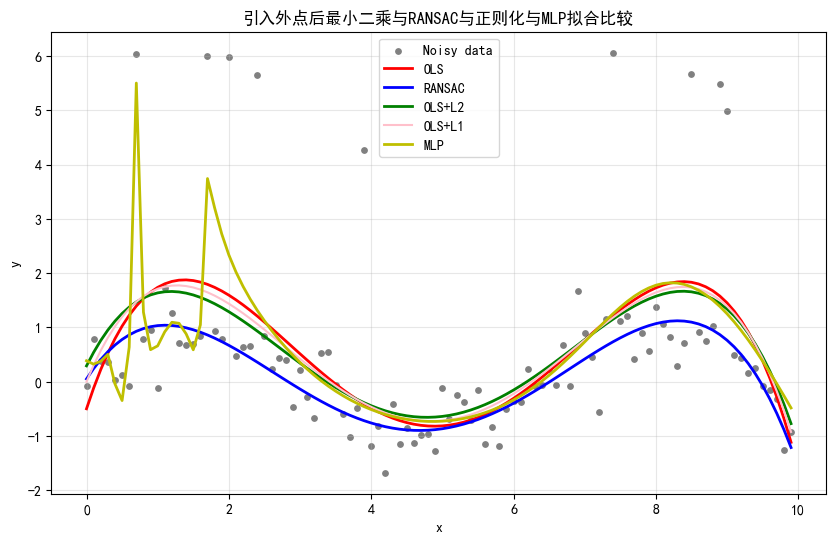

In [14]:
#引入外点
import math
import numpy as np  
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
import torch
import torch.nn as nn
import torch.optim as optim

x_lst = [i/10 for i in range(0,100)]
y_true_lst = []
for i in x_lst:
    #图像修改处
    y_true_lst.append(math.sin(i))

#噪声生成
noise_scale = 0.3
seed = 42  
np.random.seed(seed)  
noise_laplace = np.random.laplace(0, noise_scale, len(x_lst))
y_laplace_lst = [y + noise for y, noise in zip(y_true_lst, noise_laplace)]

# ---------------------- 新增：引入外点（仅此处核心修改） ----------------------
outlier_indices = np.random.choice(len(x_lst), size=20, replace=False)
for idx in outlier_indices:
    y_laplace_lst[idx] += np.random.choice([0, 5])  # 外点偏移量，可根据需求调整
# -----------------------------------------------------------------------------

#最小二乘法----------------------------------------------------
M=4
N=len(x_lst)
#矩阵设计与求解
X_mat1 = np.zeros((N, M+1))
for n in range(N):
    for j in range(M+1):
        X_mat1[n, j] = x_lst[n] ** j 
T = np.array(y_laplace_lst).reshape(-1, 1)
X_mat_T1 = X_mat1.T  
temp = np.dot(X_mat_T1, X_mat1) 
temp_inv = np.linalg.inv(temp) 
temp2 = np.dot(temp_inv, X_mat_T1)
w_opt = np.dot(temp2, T)

def predfuncxOLS(x):
    return sum(w_opt[i] * (x**i) for i in range(M+1))
Ew = 0
for i in range(N):
    Ew += 0.5 * (y_laplace_lst[i] - predfuncxOLS(x_lst[i])) ** 2

#RANSAC--------------------------------------------------------
# 转换为numpy数组（适配sklearn接口）
xRAN = np.array(x_lst).reshape(-1, 1)  # 必须是2D数组（样本数×特征数）
y_noisyRAN = np.array(y_laplace_lst)

degree = 4
# 构建RANSAC模型
ransac = make_pipeline(
    PolynomialFeatures(degree=degree),  # 生成多项式特征
    RANSACRegressor(
        min_samples=50,        # 拟合模型所需的最小样本数
        residual_threshold=0.5,# 【微调】外点场景下适当提高残差阈值（原0.1）
        random_state=seed      # 固定随机种子保证结果可复现
    )
)

ransac.fit(xRAN, y_noisyRAN)

#L2正则化-----------------------------------------------------------------
lambdax=1
fanshu2=0
qqqqq=0

X_mat2 = np.zeros((N, M+1))
for n in range(N):
    for j in range(M+1):
        X_mat2[n, j] = x_lst[n] ** j
t = np.array(y_laplace_lst).reshape(-1, 1)
X_mat_T2 = X_mat2.T
A = X_mat_T2 @ X_mat2 + lambdax * np.eye(M+1) 
b = X_mat_T2 @ t
w_opt_reg = np.linalg.solve(A, b)  


def predfuncx_reg(x):
    return sum(w_opt_reg[i] * (x ** i) for i in range(M+1))

Ew2 = 0
for i in range(N):
    Ew2 += 0.5 * (y_laplace_lst[i] - predfuncx_reg(x_lst[i])) ** 2

w_sq_sum = sum(w_opt_reg[i] ** 2 for i in range(M+1))
Ewlam2 = Ew2 + (lambdax / 2) * w_sq_sum

#L1正则化-----------------------------------------------------------------
alpha = 0.01  
X_matl1 = np.zeros((N, M+1))
for n in range(N):
    for j in range(M+1):
        X_matl1[n, j] = x_lst[n] ** j

lasso = Lasso(alpha=alpha, max_iter=100000, tol=1e-8, fit_intercept=False)
lasso.fit(X_matl1, y_laplace_lst)
w_opt_reg1 = lasso.coef_.reshape(-1, 1)  # L1正则化最优权重

def predfuncx_regl1(x):
    return sum(w_opt_reg1[i] * (x ** i) for i in range(M+1))

# 7. 计算损失函数（L1正则化目标函数）
EwL = 0  # 经验损失（均方误差）
for i in range(N):
    EwL += 0.5 * (y_laplace_lst[i] - predfuncx_regl1(x_lst[i])) ** 2

w_abs_sum = sum(abs(w_opt_reg[i]) for i in range(M+1))  # L1：权重绝对值和
Ewlam1 = EwL + alpha * w_abs_sum  # L1总损失 = 误差 + 正则项



#MLP-------------------------------------------------------------------------

# 1. 数据转张量
xmlp = torch.tensor(x_lst, dtype=torch.float32).unsqueeze(1)  # [101,1]
ymlp = torch.tensor(y_laplace_lst, dtype=torch.float32).unsqueeze(1)

# 2. 定义极简MLP：输入1维 → 隐藏层32 → 输出1维
class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32),
            nn.Tanh(),
            nn.Linear(32, 16), 
            nn.Tanh(),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.net(x)

# 3. 训练配置
model = SimpleMLP()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
epochs = 1000
# 4. 训练
print("\n开始训练MLP...")
for epoch in range(epochs):
    optimizer.zero_grad()
    pred = model(xmlp)
    loss = criterion(pred, ymlp)
    loss.backward()
    optimizer.step()
    if epoch % 300 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss.item():.6f}")

# 5. MLP预测结果
with torch.no_grad():
    y_mlp_lst = model(xmlp).squeeze().numpy()


#评价：RMS
OLSRMS=np.sqrt(Ew/N)
print("OLS均方根误差：", OLSRMS)
OLSzzRMS=np.sqrt(Ewlam2/N)
print("OLS+L2均方根误差：", OLSzzRMS)
Ew_mlp = 0.5 * np.sum((y_laplace_lst - y_mlp_lst) ** 2)
l1RMS = np.sqrt(EwL / N)
print("OLS+L1均方根误差(RMS)：", l1RMS)
RMS_MLP = np.sqrt(Ew_mlp / len(x_lst))
print("MLP 神经网络 RMS:   ", RMS_MLP)


#可视化
y_fit_lstsinOLS = [predfuncxOLS(x) for x in x_lst]
y_fit_lst2sin = [ransac.predict(np.array([[x_val]]))[0] for x_val in x_lst]
y_fit_lstzz= [predfuncx_reg(x) for x in x_lst]
y_fit_lstzz1 = [predfuncx_regl1(x) for x in x_lst]
y_mlp=y_mlp_lst
plt.rcParams['font.sans-serif'] = ['SimHei']  # 支持中文显示
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题
plt.figure(figsize=(10,6))
plt.scatter(x_lst, y_laplace_lst, c='gray', s=15, label='Noisy data')
plt.plot(x_lst, y_fit_lstsinOLS, 'r-', linewidth=2, label='OLS')
plt.plot(x_lst, y_fit_lst2sin, 'b-', linewidth=2, label='RANSAC')
plt.plot(x_lst, y_fit_lstzz, 'g-', linewidth=2, label='OLS+L2')
plt.plot(x_lst, y_fit_lstzz1, label='OLS+L1', color='pink')
plt.plot(x_lst, y_mlp, 'y-', linewidth=2, label='MLP')
plt.xlabel('x')
plt.ylabel('y')
plt.title('引入外点后最小二乘与RANSAC与正则化与MLP拟合比较')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**PART8.数学变换**

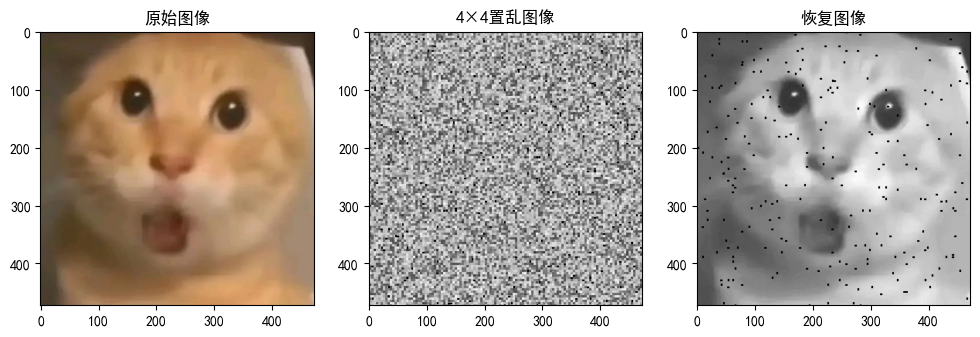

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import time

def PermutationFun(inputImage, blockwidth, blockheight, seed=None, fill_value=0):
    """
    图像分块置乱函数
    :param inputImage: 输入图像（灰度/彩色）
    :param blockwidth: 块宽度
    :param blockheight: 块高度
    :param seed: 随机种子（用于可复现置乱）
    :param fill_value: 不足块的填充值（0/255）
    :return: 置乱后的图像、块索引映射（用于恢复）、原始图像尺寸
    """
    # 1. 彩色转灰度
    if len(inputImage.shape) == 3:
        inputImage = cv2.cvtColor(inputImage, cv2.COLOR_BGR2GRAY)
    h, w = inputImage.shape

    # 2. 计算填充后的尺寸
    pad_h = (blockheight - h % blockheight) % blockheight
    pad_w = (blockwidth - w % blockwidth) % blockwidth
    padded_img = np.pad(inputImage, ((0, pad_h), (0, pad_w)), mode='constant', constant_values=fill_value)
    pad_h_total, pad_w_total = padded_img.shape

    # 3. 分块
    num_blocks_h = pad_h_total // blockheight
    num_blocks_w = pad_w_total // blockwidth
    blocks = []
    for i in range(num_blocks_h):
        for j in range(num_blocks_w):
            block = padded_img[i*blockheight:(i+1)*blockheight, j*blockwidth:(j+1)*blockwidth]
            blocks.append(block)

    # 4. 置乱块顺序
    np.random.seed(seed)
    indices = np.arange(len(blocks))
    np.random.shuffle(indices)
    shuffled_blocks = [blocks[idx] for idx in indices]

    # 5. 重组置乱图像
    shuffled_img = np.zeros_like(padded_img)
    idx = 0
    for i in range(num_blocks_h):
        for j in range(num_blocks_w):
            shuffled_img[i*blockheight:(i+1)*blockheight, j*blockwidth:(j+1)*blockwidth] = shuffled_blocks[idx]
            idx += 1

    # 6. 裁剪回原始尺寸
    shuffled_img = shuffled_img[:h, :w]
    return shuffled_img, indices, (h, w, pad_h, pad_w, blockwidth, blockheight)

def restore_shuffled_image(shuffled_img, indices, params, fill_value=0):
    """
    恢复置乱后的图像
    :param shuffled_img: 置乱后的图像
    :param indices: 置乱时的块索引映射
    :param params: PermutationFun返回的尺寸参数
    :param fill_value: 填充值
    :return: 恢复后的图像
    """
    h, w, pad_h, pad_w, blockwidth, blockheight = params
    pad_h_total = h + pad_h
    pad_w_total = w + pad_w

    # 1. 填充置乱图像
    padded_shuffled = np.pad(shuffled_img, ((0, pad_h), (0, pad_w)), mode='constant', constant_values=fill_value)
    num_blocks_h = pad_h_total // blockheight
    num_blocks_w = pad_w_total // blockwidth

    # 2. 分块
    shuffled_blocks = []
    for i in range(num_blocks_h):
        for j in range(num_blocks_w):
            block = padded_shuffled[i*blockheight:(i+1)*blockheight, j*blockwidth:(j+1)*blockwidth]
            shuffled_blocks.append(block)

    # 3. 逆置乱
    restored_blocks = [None] * len(indices)
    for new_idx, old_idx in enumerate(indices):
        restored_blocks[old_idx] = shuffled_blocks[new_idx]

    # 4. 重组图像
    restored_img = np.zeros_like(padded_shuffled)
    idx = 0
    for i in range(num_blocks_h):
        for j in range(num_blocks_w):
            restored_img[i*blockheight:(i+1)*blockheight, j*blockwidth:(j+1)*blockwidth] = restored_blocks[idx]
            idx += 1

    # 5. 裁剪回原始尺寸
    restored_img = restored_img[:h, :w]
    return restored_img

# 读取图像
img = cv2.imread('maodie.png')
# 4×4分块置乱
shuffled_img, indices, params = PermutationFun(img, blockwidth=4, blockheight=4, seed=42)
# 恢复图像
restored_img = restore_shuffled_image(shuffled_img, indices, params)

# 显示结果
plt.rcParams['font.sans-serif'] = ['SimHei']  # 支持中文显示
plt.figure(figsize=(12,4))
plt.subplot(131), plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)), plt.title('原始图像')
plt.subplot(132), plt.imshow(shuffled_img, cmap='gray'), plt.title('4×4置乱图像')
plt.subplot(133), plt.imshow(restored_img, cmap='gray'), plt.title('恢复图像')
plt.show()

In [16]:
def dft_2d(block):
    """二维离散傅里叶变换（手动实现，也可使用np.fft.fft2）"""
    M, N = block.shape
    u = np.arange(M).reshape(-1,1)
    v = np.arange(N).reshape(1,-1)
    x = np.arange(M).reshape(1,-1)
    y = np.arange(N).reshape(-1,1)
    # DFT核
    kernel = np.exp(-2j * np.pi * (u @ x / M + v @ y / N))
    return kernel @ block @ kernel.T

def idft_2d(dft_block):
    """二维离散傅里叶逆变换"""
    M, N = dft_block.shape
    u = np.arange(M).reshape(-1,1)
    v = np.arange(N).reshape(1,-1)
    x = np.arange(M).reshape(1,-1)
    y = np.arange(N).reshape(-1,1)
    # IDFT核
    kernel = np.exp(2j * np.pi * (u @ x / M + v @ y / N)) / (M*N)
    return np.round(np.real(kernel @ dft_block @ kernel.T)).astype(np.uint8)

def dft_experiment(img_path, block_size=8):
    # 1. 读取RGB图像并转YCbCr，增加非空校验
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"未找到图像文件：{img_path}，请检查路径是否正确！")
    img_ycbcr = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
    Y, Cr, Cb = cv2.split(img_ycbcr)
    oh, ow = Y.shape  # 保存原始尺寸，用于最后裁剪
    
    # ========== 关键修复：整体补零到8的整数倍 ==========
    pad_h = (block_size - oh % block_size) % block_size
    pad_w = (block_size - ow % block_size) % block_size
    Y = np.pad(Y, ((0, pad_h), (0, pad_w)), mode='constant')  # 补零后全为8×8块
    h, w = Y.shape
    # ==================================================
    
    # 2. 分块8×8 DFT变换（计时）
    start_time = time.time()
    dft_Y = np.zeros_like(Y, dtype=np.complex128)
    for i in range(0, h, block_size):
        for j in range(0, w, block_size):
            block = Y[i:i+block_size, j:j+block_size]  # 现在全是8×8，无需单独补零
            # DFT变换（使用np.fft.fft2加速，手动实现可替换）
            dft_block = np.fft.fft2(block)
            # 频谱中心化
            dft_block = np.fft.fftshift(dft_block)
            dft_Y[i:i+block_size, j:j+block_size] = dft_block  # 形状匹配，无报错
    dft_time = time.time() - start_time
    print(f"分块8×8 DFT总耗时: {dft_time:.4f}s")

    # 3. 计算幅度谱、相位谱、能量谱
    amplitude = np.abs(dft_Y)
    phase = np.angle(dft_Y)
    energy = amplitude ** 2

    # 4. 归一化转灰度图（裁剪回原始尺寸后再保存/显示）
    amp_gray = cv2.normalize(np.log(amplitude + 1), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)[:oh, :ow]
    phase_gray = cv2.normalize(phase, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)[:oh, :ow]
    energy_gray = cv2.normalize(np.log(energy + 1), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)[:oh, :ow]
    cv2.imwrite('dft_amplitude.jpg', amp_gray)
    cv2.imwrite('dft_phase.jpg', phase_gray)
    cv2.imwrite('dft_energy.jpg', energy_gray)

    # 5. 仅保留幅度/相位的逆变换
    # 仅幅度（相位置0）
    amp_only = amplitude * np.exp(1j * 0)
    # 仅相位（幅度置1）
    phase_only = np.ones_like(amplitude) * np.exp(1j * phase)

    # 逆变换（内部裁剪回原始尺寸）
    def idft_reconstruct(dft_data, block_size=8):
        h_d, w_d = dft_data.shape
        recon = np.zeros_like(dft_data, dtype=np.uint8)
        for i in range(0, h_d, block_size):
            for j in range(0, w_d, block_size):
                block = dft_data[i:i+block_size, j:j+block_size]
                block = np.fft.ifftshift(block)
                idft_block = np.fft.ifft2(block)
                idft_block = np.round(np.real(idft_block)).astype(np.uint8)
                recon[i:i+block_size, j:j+block_size] = idft_block
        return recon[:oh, :ow]  # 裁剪回图像原始尺寸

    recon_amp = idft_reconstruct(amp_only)
    recon_phase = idft_reconstruct(phase_only)

    # 6. 显示结果
    plt.figure(figsize=(15,10))
    plt.subplot(231), plt.imshow(Y[:oh, :ow], cmap='gray'), plt.title('原始Y分量')
    plt.subplot(232), plt.imshow(amp_gray, cmap='gray'), plt.title('幅度谱')
    plt.subplot(233), plt.imshow(phase_gray, cmap='gray'), plt.title('相位谱')
    plt.subplot(234), plt.imshow(energy_gray, cmap='gray'), plt.title('能量谱')
    plt.subplot(235), plt.imshow(recon_amp, cmap='gray'), plt.title('仅幅度逆变换')
    plt.subplot(236), plt.imshow(recon_phase, cmap='gray'), plt.title('仅相位逆变换')
    plt.tight_layout()
    plt.show()
    return Y[:oh, :ow], amp_gray, phase_gray, energy_gray, recon_amp, recon_phase



In [17]:
def dct_2d(block):
    """二维离散余弦变换（手动实现，也可使用cv2.dct）"""
    M, N = block.shape
    # DCT系数矩阵
    alpha = np.ones((M,N))
    alpha[0,:] = 1 / np.sqrt(2)
    alpha[:,0] = 1 / np.sqrt(2)
    alpha[0,0] = 1 / 2

    u = np.arange(M).reshape(-1,1)
    v = np.arange(N).reshape(1,-1)
    x = np.arange(M).reshape(1,-1)
    y = np.arange(N).reshape(-1,1)

    # DCT核
    kernel_u = np.cos((2*x + 1) * u * np.pi / (2*M))
    kernel_v = np.cos((2*y + 1) * v * np.pi / (2*N))
    return 2 * alpha * (kernel_u.T @ block @ kernel_v) / np.sqrt(M*N)

def idct_2d(dct_block):
    """二维离散余弦逆变换"""
    M, N = dct_block.shape
    alpha = np.ones((M,N))
    alpha[0,:] = 1 / np.sqrt(2)
    alpha[:,0] = 1 / np.sqrt(2)
    alpha[0,0] = 1 / 2

    u = np.arange(M).reshape(-1,1)
    v = np.arange(N).reshape(1,-1)
    x = np.arange(M).reshape(1,-1)
    y = np.arange(N).reshape(-1,1)

    # IDCT核
    kernel_u = np.cos((2*x + 1) * u * np.pi / (2*M))
    kernel_v = np.cos((2*y + 1) * v * np.pi / (2*N))
    return np.round(np.real(kernel_u @ (alpha * dct_block) @ kernel_v.T)).astype(np.uint8)

def show_dct_basis(block_size=8):
    """显示8×8 DCT基函数图像"""
    fig, axes = plt.subplots(block_size, block_size, figsize=(10,10))
    for u in range(block_size):
        for v in range(block_size):
            # 生成基函数
            x, y = np.meshgrid(np.arange(block_size), np.arange(block_size))
            basis = np.cos((2*x+1)*u*np.pi/(2*block_size)) * np.cos((2*y+1)*v*np.pi/(2*block_size))
            axes[u,v].imshow(basis, cmap='gray')
            axes[u,v].axis('off')
    plt.suptitle('8×8 DCT基函数图像', fontsize=16)
    plt.tight_layout()
    plt.show()

def dct_via_fft(block):
    """用FFT实现二维DCT"""
    M, N = block.shape
    # 1. 行方向DCT
    x = np.zeros((M, 2*N))
    x[:, :N] = block
    x[:, N:] = np.fliplr(block)
    fft_row = np.fft.fft(x, axis=1)
    k = np.arange(N)
    dct_row = np.sqrt(2/N) * np.real(fft_row[:, :N] * np.exp(-1j * np.pi * k / (2*N)))
    dct_row[:, 0] /= np.sqrt(2)

    # 2. 列方向DCT
    y = np.zeros((2*M, N))
    y[:M, :] = dct_row
    y[M:, :] = np.flipud(dct_row)
    fft_col = np.fft.fft(y, axis=0)
    l = np.arange(M).reshape(-1,1)
    dct_col = np.sqrt(2/M) * np.real(fft_col[:M, :] * np.exp(-1j * np.pi * l / (2*M)))
    dct_col[0, :] /= np.sqrt(2)
    return dct_col

In [18]:
def zigzag_indices(n=8):
    """生成8×8矩阵的Zig-Zag扫描索引"""
    idx = []
    for s in range(2*n - 1):
        if s < n:
            start = 0
            end = s + 1
        else:
            start = s - n + 1
            end = n
        for i in range(start, end):
            j = s - i
            if s % 2 == 0:
                idx.append((j, i))
            else:
                idx.append((i, j))
    return idx

zigzag_idx = zigzag_indices(8)


def dct_energy_analysis(img_path, keep_counts=[1,2,4,6,8,10], block_size=8):
    # 1. 读取图像转灰度，增加非空校验
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"未找到图像文件：{img_path}，请检查路径是否正确！")
    oh, ow = img.shape  # 保存原始尺寸
    results = []
    
    # ========== 关键修复：整体补零到8的整数倍 ==========
    pad_h = (block_size - oh % block_size) % block_size
    pad_w = (block_size - ow % block_size) % block_size
    img = np.pad(img, ((0, pad_h), (0, pad_w)), mode='constant')
    h, w = img.shape
    # ==================================================

    # 2. 分块DCT变换（全8×8块，无需单独补零）
    dct_img = np.zeros_like(img, dtype=np.float32)
    for i in range(0, h, block_size):
        for j in range(0, w, block_size):
            block = img[i:i+block_size, j:j+block_size]
            dct_block = cv2.dct(block.astype(np.float32))
            dct_img[i:i+block_size, j:j+block_size] = dct_block

    # 3. 对每个保留系数数做重构
    for k in keep_counts:
        # 按Zig-Zag保留前k个系数，其余置0
        mask = np.zeros((block_size, block_size), dtype=np.uint8)
        for idx in range(k):
            if idx >= len(zigzag_idx):
                break
            u, v = zigzag_idx[idx]
            mask[u, v] = 1
        # 分块应用掩码
        masked_dct = np.zeros_like(dct_img)
        for i in range(0, h, block_size):
            for j in range(0, w, block_size):
                block = dct_img[i:i+block_size, j:j+block_size]
                masked_dct[i:i+block_size, j:j+block_size] = block * mask
        # 逆DCT重构
        recon_img = np.zeros_like(img, dtype=np.uint8)
        for i in range(0, h, block_size):
            for j in range(0, w, block_size):
                block = masked_dct[i:i+block_size, j:j+block_size]
                idct_block = cv2.idct(block)
                idct_block = np.clip(idct_block, 0, 255).astype(np.uint8)
                recon_img[i:i+block_size, j:j+block_size] = idct_block
        # 裁剪回原始尺寸
        recon_img = recon_img[:oh, :ow]
        # 计算PSNR和SSIM（兼容新版skimage，增加data_range）
        psnr_val = psnr(img[:oh, :ow], recon_img, data_range=255)
        ssim_val = ssim(img[:oh, :ow], recon_img, data_range=255, channel_axis=None)
        results.append((k, psnr_val, ssim_val, recon_img))
        print(f"保留{k}个系数: PSNR={psnr_val:.2f}dB, SSIM={ssim_val:.4f}")

    # 4. 显示重构结果
    plt.figure(figsize=(15, 8))
    plt.subplot(2, 4, 1), plt.imshow(img[:oh, :ow], cmap='gray'), plt.title('原始图像')
    for idx, (k, psnr_val, ssim_val, recon) in enumerate(results):
        plt.subplot(2, 4, idx+2)
        plt.imshow(recon, cmap='gray')
        plt.title(f'保留{k}个系数\nPSNR={psnr_val:.1f}dB\nSSIM={ssim_val:.3f}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    return results


分块8×8 DFT总耗时: 0.3534s


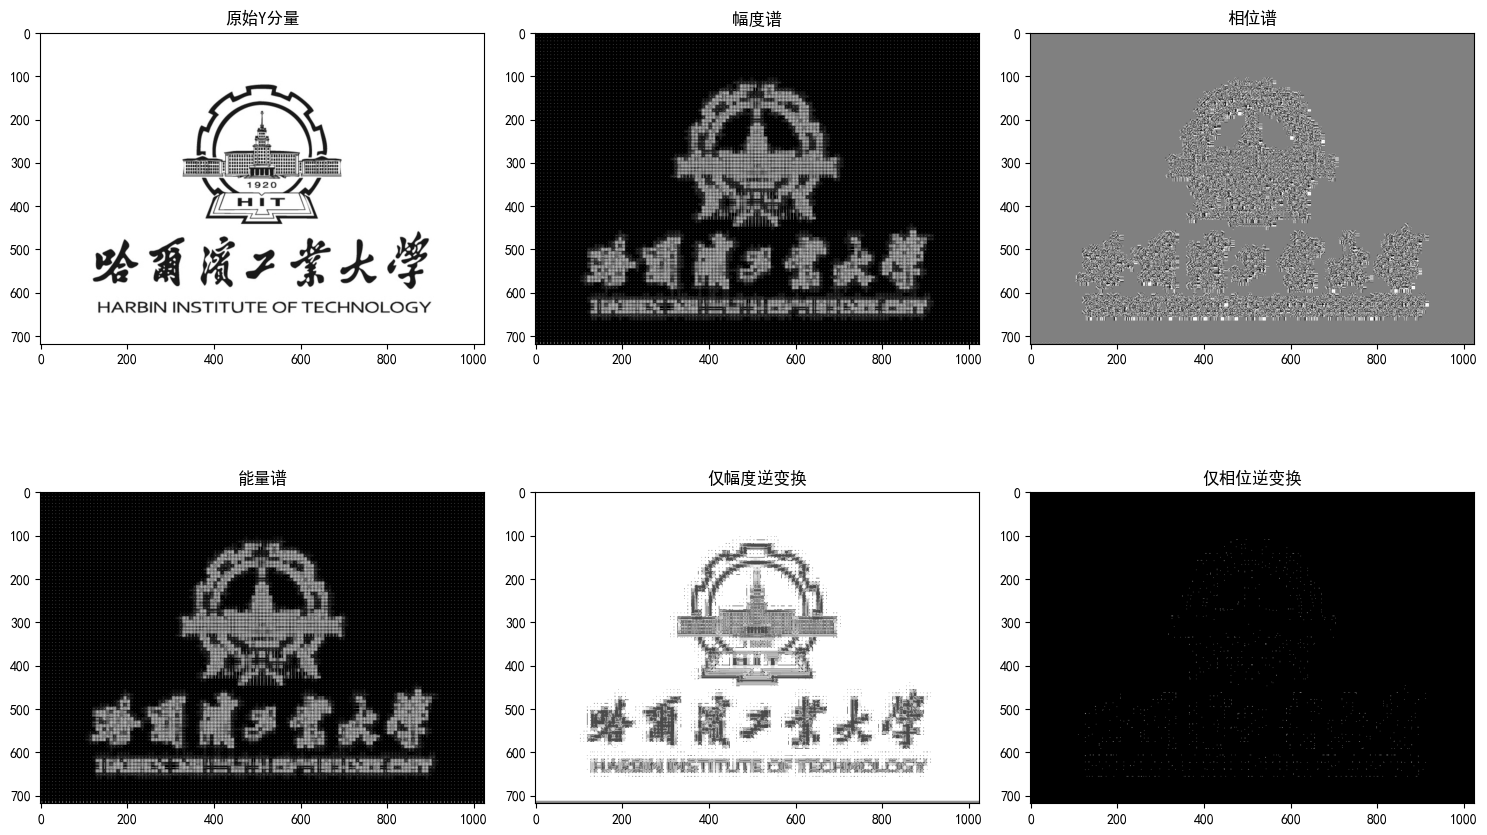

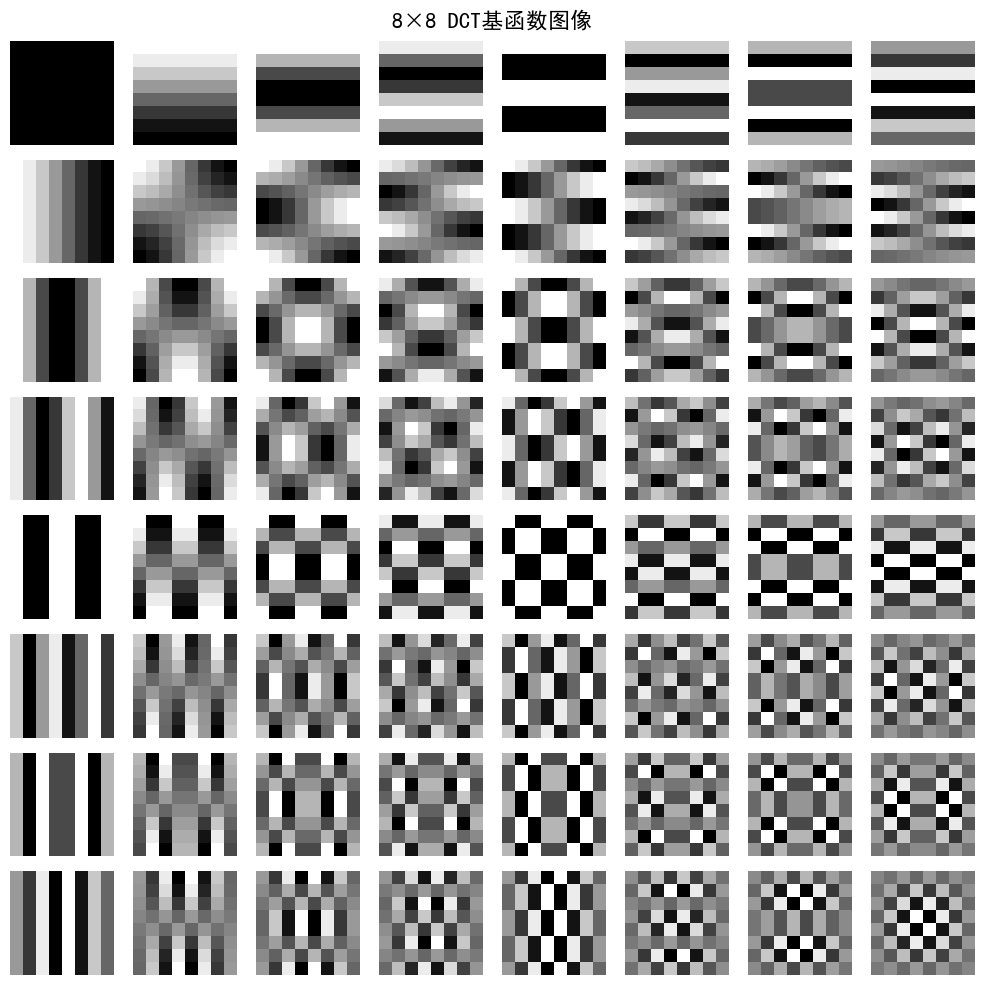

保留1个系数: PSNR=20.23dB, SSIM=0.8440
保留2个系数: PSNR=21.46dB, SSIM=0.8766
保留4个系数: PSNR=24.88dB, SSIM=0.9304
保留6个系数: PSNR=27.02dB, SSIM=0.9496
保留8个系数: PSNR=28.21dB, SSIM=0.9595
保留10个系数: PSNR=30.23dB, SSIM=0.9722


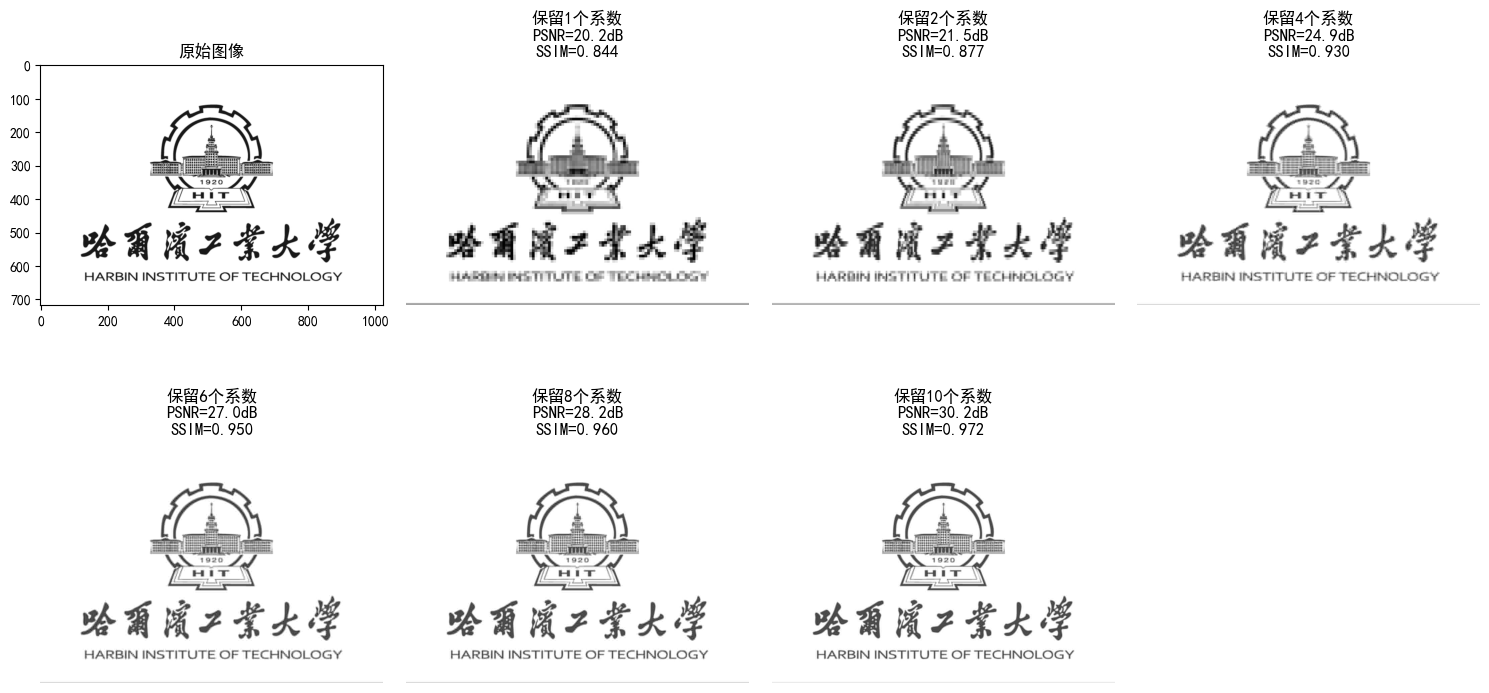

In [19]:
if __name__ == '__main__':
    # 1. 分块置乱实验
    img = cv2.imread('HIT.jpg')
    shuffled_img, indices, params = PermutationFun(img, 8, 8, seed=42)
    restored_img = restore_shuffled_image(shuffled_img, indices, params)

    # 2. DFT实验
    Y, amp, phase, energy, recon_amp, recon_phase = dft_experiment('HIT.jpg')

    # 3. DCT基函数显示
    show_dct_basis(8)

    # 4. DCT能量聚集性分析
    results = dct_energy_analysis('HIT.jpg', keep_counts=[1,2,4,6,8,10])